Loaded 274 realizations with 8 theta bins (use_fkp=True).


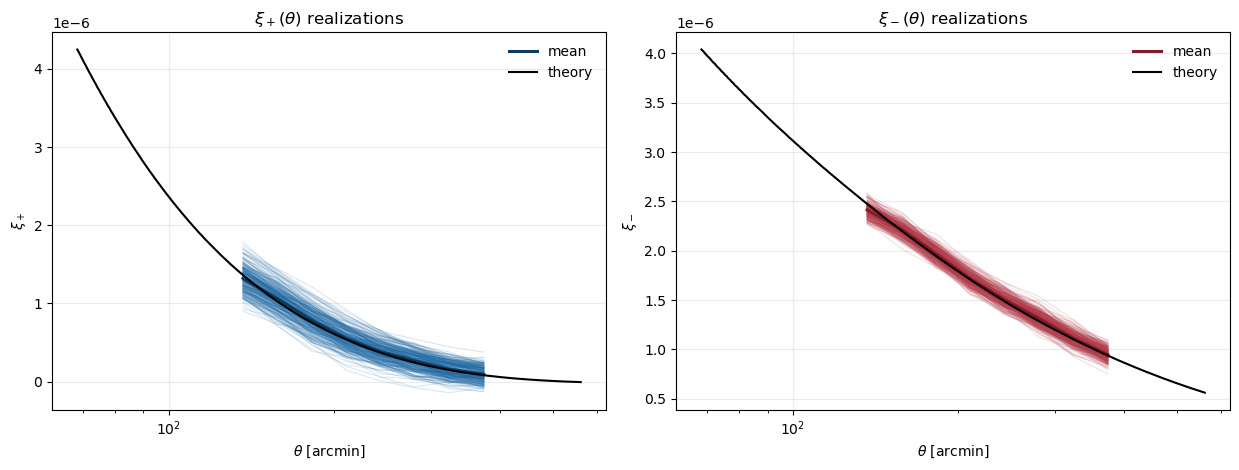

cov_xip shape: (8, 8)
cov_xim shape: (8, 8)
cov_joint shape: (16, 16)
SNR(xi+)           = 8.578
SNR(xi-)           = 45.926
SNR(total joint)   = 47.606
Hartlap factor     = 0.9377
SNR(total, Hartlap)= 46.100


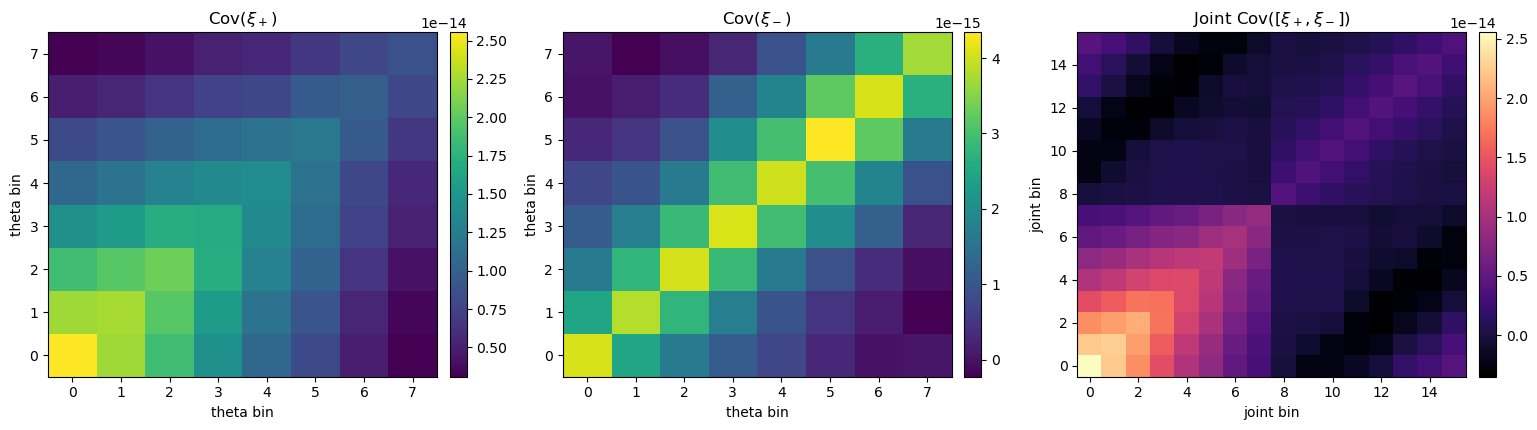

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#npz_path = "/Users/robert/Documents/Git/qml_ec/output/xi_pm_realisations_uniform.npz"
npz_path = "/Users/robert/Documents/Git/qml_ec/output/xi_pm_realisations_fkp.npz"
d = np.load(npz_path)

theta = d["theta"]
xip = d["xip"]  # shape: (n_real, n_theta)
xim = d["xim"]  # shape: (n_real, n_theta)
use_fkp = bool(d["use_fkp"])

theta_th = d["theta_th"]   # arcmin, finer grid
xi_p_th  = d["xi_p_th"]
xi_m_th  = d["xi_m_th"]

n_real, n_theta = xip.shape
print(f"Loaded {n_real} realizations with {n_theta} theta bins (use_fkp={use_fkp}).")

# Plot all realizations and the mean curve for xi+ and xi-
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True)

for i in range(n_real):
    axes[0].plot(theta, xip[i], color="#1f6aa5", alpha=0.16, lw=0.8)
    axes[1].plot(theta, xim[i], color="#b23a48", alpha=0.16, lw=0.8)

axes[0].plot(theta, xip.mean(axis=0), color="#0b3c5d", lw=2.2, label="mean")
axes[1].plot(theta, xim.mean(axis=0), color="#7f1d2d", lw=2.2, label="mean")

axes[0].plot(theta_th, xi_p_th, "k-", lw=1.5, label="theory")
axes[1].plot(theta_th, xi_m_th, "k-", lw=1.5, label="theory")

axes[0].set_title(r"$\xi_+(\theta)$ realizations")
axes[1].set_title(r"$\xi_-(\theta)$ realizations")
for ax, ylab in zip(axes, [r"$\xi_+$", r"$\xi_-$"]):
    ax.set_xlabel(r"$\theta$ [arcmin]")
    ax.set_ylabel(ylab)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()

# Covariance matrices
cov_xip = np.cov(xip, rowvar=False, ddof=1)   # (n_theta, n_theta)
cov_xim = np.cov(xim, rowvar=False, ddof=1)   # (n_theta, n_theta)

# Joint covariance for [xi+, xi-]
xi_joint = np.concatenate([xip, xim], axis=1)  # (n_real, 2*n_theta)
cov_joint = np.cov(xi_joint, rowvar=False, ddof=1)  # (2*n_theta, 2*n_theta)

print("cov_xip shape:", cov_xip.shape)
print("cov_xim shape:", cov_xim.shape)
print("cov_joint shape:", cov_joint.shape)

# Signal-to-noise ratio estimates: SNR^2 = mu^T C^{-1} mu
# Use pseudo-inverse for numerical stability.
mu_xip = xip.mean(axis=0)
mu_xim = xim.mean(axis=0)
mu_joint = np.concatenate([mu_xip, mu_xim])

inv_cov_xip = np.linalg.pinv(cov_xip)
inv_cov_xim = np.linalg.pinv(cov_xim)
inv_cov_joint = np.linalg.pinv(cov_joint)

snr2_xip = float(mu_xip @ inv_cov_xip @ mu_xip)
snr2_xim = float(mu_xim @ inv_cov_xim @ mu_xim)
snr2_joint = float(mu_joint @ inv_cov_joint @ mu_joint)

snr_xip = np.sqrt(max(snr2_xip, 0.0))
snr_xim = np.sqrt(max(snr2_xim, 0.0))
snr_joint = np.sqrt(max(snr2_joint, 0.0))

# Hartlap correction (for inverse covariance bias from finite realizations)
p_joint = 2 * n_theta
hartlap = (n_real - p_joint - 2) / (n_real - 1) if n_real > p_joint + 2 else np.nan
snr_joint_hartlap = np.sqrt(max(hartlap * snr2_joint, 0.0)) if np.isfinite(hartlap) else np.nan

print(f"SNR(xi+)           = {snr_xip:.3f}")
print(f"SNR(xi-)           = {snr_xim:.3f}")
print(f"SNR(total joint)   = {snr_joint:.3f}")
if np.isfinite(hartlap):
    print(f"Hartlap factor     = {hartlap:.4f}")
    print(f"SNR(total, Hartlap)= {snr_joint_hartlap:.3f}")

# Visualize covariance blocks
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

im0 = axes[0].imshow(cov_xip, origin="lower", aspect="auto", cmap="viridis")
axes[0].set_title(r"Cov$(\xi_+)$")
axes[0].set_xlabel("theta bin")
axes[0].set_ylabel("theta bin")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)

im1 = axes[1].imshow(cov_xim, origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title(r"Cov$(\xi_-)$")
axes[1].set_xlabel("theta bin")
axes[1].set_ylabel("theta bin")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)

im2 = axes[2].imshow(cov_joint, origin="lower", aspect="auto", cmap="magma")
axes[2].set_title(r"Joint Cov$([\xi_+,\xi_-])$")
axes[2].set_xlabel("joint bin")
axes[2].set_ylabel("joint bin")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.03)

fig.tight_layout()
plt.show()